## Import library

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Load data


In [46]:
df = pd.read_csv('penjualan_2025.csv')
df.head()

,tanggal,kategori,region,harga_satuan,unit_terjual,diskon_persen,pendapatan_kotor,pendapatan_bersih
0,2025-01-01,Fashion,Bandung,242409.0,10,0.21,2424085.0,1915027.0
1,2025-01-02,Buku,Jakarta,111460.0,11,0.10,1226058.0,1103452.0
2,2025-01-03,Olahraga,Jakarta,398061.0,8,0.20,3184485.0,2547588.0
3,2025-01-04,Makanan,Surabaya,74480.0,6,0.12,446879.0,393254.0
4,2025-01-05,Elektronik,Bandung,1271857.0,8,0.23,10174858.0,7834641.0


In [47]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tanggal            365 non-null    object 
 1   kategori           365 non-null    object 
 2   region             365 non-null    object 
 3   harga_satuan       365 non-null    float64
 4   unit_terjual       365 non-null    int64  
 5   diskon_persen      365 non-null    float64
 6   pendapatan_kotor   365 non-null    float64
 7   pendapatan_bersih  365 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 22.9+ KB


,harga_satuan,unit_terjual,diskon_persen,pendapatan_kotor,pendapatan_bersih
count,3.650000e+02,365.000000,365.000000,3.650000e+02,3.650000e+02
mean,5.534436e+05,8.857534,0.146986,4.855862e+06,4.180401e+06
std,5.774970e+05,2.674971,0.084569,5.344345e+06,4.686099e+06
min,6.441600e+04,3.000000,0.000000,2.121510e+05,1.845710e+05
25%,1.033610e+05,7.000000,0.070000,9.792420e+05,8.016760e+05
50%,3.030830e+05,9.000000,0.150000,2.544127e+06,2.185323e+06
75%,1.220119e+06,11.000000,0.220000,6.895839e+06,6.298013e+06
max,1.791909e+06,17.000000,0.300000,2.237371e+07,2.080755e+07


In [48]:
pendapatan = df['pendapatan_bersih'].to_numpy()
total = np.sum(pendapatan)
rata2 = np.mean(pendapatan)
median = np.median(pendapatan)
standar = np.std(pendapatan)

print(f'Total pendapatan bersih     : Rp {total:,.0f}')
print(f'Rata-rata pendapatan bersih : Rp {rata2:,.0f}')
print(f'Median pendapatan bersih    : Rp {median:,.0f}')
print(f'Standar pendapatan bersih   : Rp {standar:,.0f}')


Total pendapatan bersih     : Rp 1,525,846,231
Rata-rata pendapatan bersih : Rp 4,180,401
Median pendapatan bersih    : Rp 2,185,323
Standar pendapatan bersih   : Rp 4,679,675


## Analisis dengan pandas

In [49]:
pendapatan_per_kategori = df.groupby('kategori')['pendapatan_bersih'].sum().sort_values(ascending=False)
pendapatan_per_kategori

kategori
Elektronik    1.062573e+09
Olahraga      1.864058e+08
Fashion       1.793341e+08
Makanan       4.958548e+07
Buku          4.794742e+07
Name: pendapatan_bersih, dtype: float64

In [50]:
pendapatan_per_region = df.groupby('region')['pendapatan_bersih'].sum().sort_values(ascending=False)
pendapatan_per_region

region
Batam       386089692.0
Jakarta     346190940.0
Bandung     275375565.0
Surabaya    273142646.0
Medan       245047388.0
Name: pendapatan_bersih, dtype: float64

In [51]:
df['tanggal'] = pd.to_datetime(df['tanggal'])
df['bulan'] = df['tanggal'].dt.to_period('M')
tren_bulanan = df.groupby('bulan')['pendapatan_bersih'].sum().sort_values(ascending=False)
tren_bulanan

bulan
2025-06    165554568.0
2025-01    161581149.0
2025-07    141944110.0
2025-04    140233424.0
2025-03    135146016.0
2025-05    126736387.0
2025-02    124501386.0
2025-10    122562117.0
2025-12    112284707.0
2025-11    109257249.0
2025-08    103635277.0
2025-09     82409841.0
Freq: M, Name: pendapatan_bersih, dtype: float64

## Visualisasi dengan matplotlib

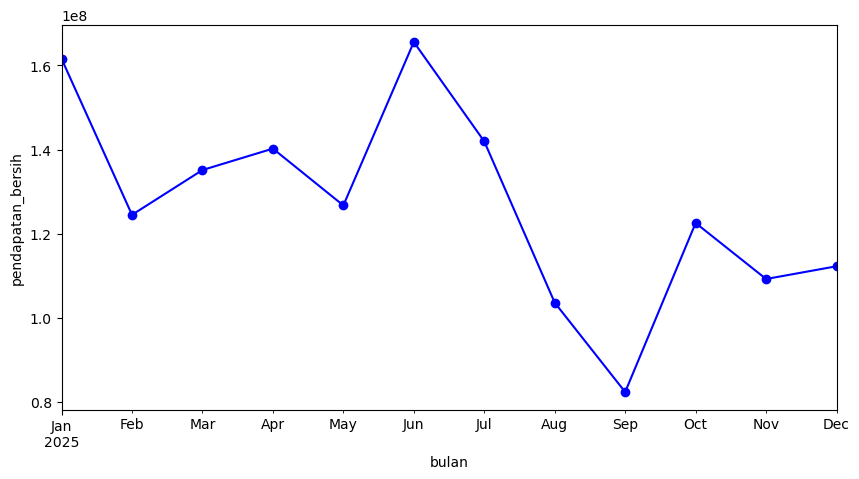

In [58]:
tren_bulanan = tren_bulanan.sort_index()
fig, ax = plt.subplots(figsize=(10,5))
tren_bulanan.plot(kind='line', marker='o',ax=ax, color='blue')
ax.set_xlabel('bulan')
ax.set_ylabel('pendapatan_bersih')
plt.show()

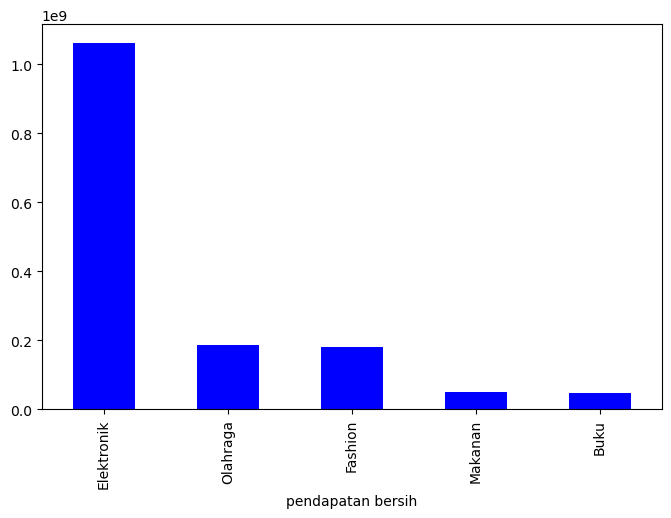

In [56]:
fig, ax = plt.subplots(figsize=(8,5))
pendapatan_per_kategori.plot(kind='bar', ax=ax, color='blue')
ax.set_xlabel('kategori')
ax.set_xlabel('pendapatan bersih')
plt.show()

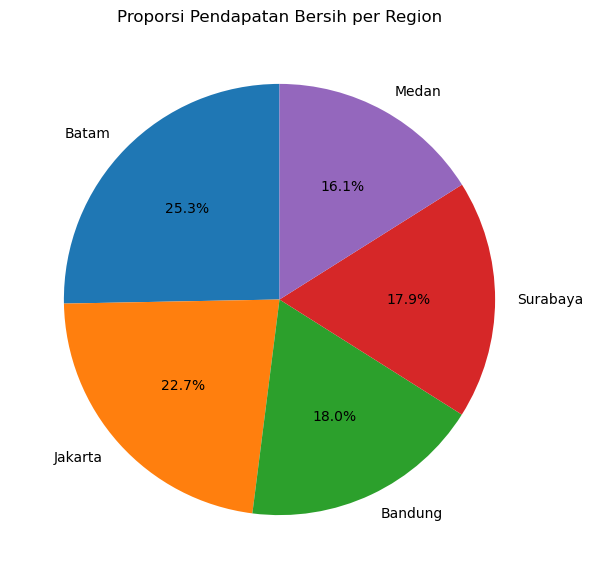

In [59]:
fig, ax = plt.subplots(figsize=(7,7))
ax.pie(pendapatan_per_region, labels=pendapatan_per_region.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Proporsi Pendapatan Bersih per Region')
plt.show()